<a href="https://colab.research.google.com/github/beswayam/deep_learning_project/blob/main/simulated_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIN31306 Bioinformatics Project 2026
## Simulated data experiments — CNN, RNN, LSTM, GRU

Predicting whether a protein performs a certain function based on its amino acid sequence.

**Fixes in this version:**
- Small dataset (200aa) uses `dropout=0.0` — dropout=0.2 was too aggressive for only 700 training sequences
- Section 11 now passes per-dataset dropout so the small dataset gets the right setting
- `nr2` dataset gets more epochs (100) and more patience (15) since it's the hardest one

## Imports

In [20]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Get the data

In [21]:
if not os.path.exists("grs34806-deep-learning-project-data"):
    os.system("git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git")

os.chdir("grs34806-deep-learning-project-data")
print("Files available:", os.listdir("."))

Files available: ['test_set_filt.f', 'GO_3A0043066.annotprot', 'len200_500_n5000nr3.pos', 'len200_500_n5000nr2.pos', 'GO_3A0007165.annotprot', 'len200_500_n5000nr4.pos', 'len200_500_n5000nr1.seq', 'len100_200_n1000.seq', 'len200_500_n1000.seq', 'len200_500_n5000nr3.seq', 'len100_200_n1000.pos', 'expr5Tseq_filtGO_100-1000.lis', '.git', 'len200_500_n5000nr2.seq', 'len200_500_n1000.pos', 'len200_500_n5000nr4.seq', 'len200_500_n5000nr1.pos', 'GO_3A0055085.annotprot', 'GO_3A0005576.annotprot', 'GO_3A0005739.annotprot']


## 2. Data loading and preprocessing

In [22]:
# amino acid -> integer mapping (from project PDF skeleton)
mapaa2num  = {aa: i for i, aa in enumerate(list("ACDEFGHIKLMNPQRSTVWY"))}
NON_AA_NUM = 20   # used for unknown characters and padding
VOCAB_SIZE  = 21  # 20 amino acids + 1 for padding/unknown


def read(seqfile, posfile):
    # reads sequences from .seq and positive IDs from .pos
    # returns list of sequences and list of 0/1 labels
    sequences = {}
    with open(seqfile) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            sequences[parts[0]] = parts[1]

    positive_ids = set()
    with open(posfile) as f:
        for line in f:
            line = line.strip()
            if line:
                positive_ids.add(line)

    datalist, labellist = [], []
    for seq_id, seq in sequences.items():
        datalist.append(seq)
        labellist.append(1 if seq_id in positive_ids else 0)

    return datalist, labellist


def generate_train_val_test(datalist, labellist, val_size=0.15, test_size=0.15):
    # three-way 70/15/15 split, stratified so class balance is preserved
    train_val_seqs, test_seqs, train_val_labs, test_labs = train_test_split(
        datalist, labellist,
        test_size=test_size, random_state=42, stratify=labellist
    )
    val_proportion = val_size / (1 - test_size)
    train_seqs, val_seqs, train_labs, val_labs = train_test_split(
        train_val_seqs, train_val_labs,
        test_size=val_proportion, random_state=42, stratify=train_val_labs
    )
    return train_seqs, val_seqs, test_seqs, train_labs, val_labs, test_labs


def tokenize(dat, map2num, non_aa_num=NON_AA_NUM):
    seq = []
    for count, i in enumerate(dat):
        seq.append([map2num.get(j, non_aa_num) for j in list(i)])
    return seq


def truncate_pad(line, num_steps, padding_token):
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))


def build_seq_array(lines, num_steps, non_aa_num=NON_AA_NUM):
    array = torch.tensor([
        truncate_pad(l, num_steps, non_aa_num) for l in lines
    ])
    return array


def build_one_hot_array(lines, num_steps, vocab_size=VOCAB_SIZE, non_aa_num=NON_AA_NUM):
    # one-hot encode for Conv1d — channels first, shape (N, vocab_size, num_steps)
    indices = build_seq_array(lines, num_steps, non_aa_num)
    N = indices.shape[0]
    one_hot = torch.zeros(N, vocab_size, num_steps)
    for i in range(N):
        for t in range(num_steps):
            one_hot[i, indices[i, t], t] = 1.0
    return one_hot


def load_data(batch_size, num_steps, dataset, one_hot_enc=True, shuffle=True):
    # one_hot_enc=True for CNN, False for RNN/LSTM/GRU
    # shuffle=False for val and test loaders
    seq, lab = dataset
    seq_tok   = tokenize(seq, mapaa2num)
    seq_array = build_one_hot_array(seq_tok, num_steps) if one_hot_enc \
                else build_seq_array(seq_tok, num_steps)
    lab_tensor = torch.tensor(lab, dtype=torch.long)
    return DataLoader(
        TensorDataset(seq_array, lab_tensor),
        batch_size=batch_size, shuffle=shuffle
    )

## 3. Load the first dataset

Start with the smallest one (1000 sequences, 100-200 aa). 70/15/15 split.

In [23]:
BATCH_SIZE = 64
NUM_STEPS  = 200   # pad/truncate to this length for the small dataset
EPOCHS     = 60    # high ceiling — early stopping will cut it short
PATIENCE   = 10    # stop if val loss doesn't improve for 10 epochs
HIDDEN     = 64    # hidden size for RNN-based models

datalist, labellist = read("len100_200_n1000.seq", "len100_200_n1000.pos")

print(f"Total sequences  : {len(datalist)}")
print(f"Positive (label=1): {sum(labellist)}")
print(f"Negative (label=0): {sum(1 for l in labellist if l==0)}")
print(f"Sequence lengths  : {min(len(s) for s in datalist)} - {max(len(s) for s in datalist)}")

Total sequences  : 1000
Positive (label=1): 507
Negative (label=0): 493
Sequence lengths  : 101 - 199


In [24]:
train_seqs, val_seqs, test_seqs, train_labs, val_labs, test_labs = \
    generate_train_val_test(datalist, labellist)

print(f"Train: {len(train_seqs)} | Val: {len(val_seqs)} | Test: {len(test_seqs)}")

# CNN loaders
train_iter_cnn = load_data(BATCH_SIZE, NUM_STEPS, (train_seqs, train_labs), one_hot_enc=True)
val_iter_cnn   = load_data(BATCH_SIZE, NUM_STEPS, (val_seqs,   val_labs),   one_hot_enc=True,  shuffle=False)
test_iter_cnn  = load_data(BATCH_SIZE, NUM_STEPS, (test_seqs,  test_labs),  one_hot_enc=True,  shuffle=False)

# RNN/LSTM/GRU loaders
train_iter_rnn = load_data(BATCH_SIZE, NUM_STEPS, (train_seqs, train_labs), one_hot_enc=False)
val_iter_rnn   = load_data(BATCH_SIZE, NUM_STEPS, (val_seqs,   val_labs),   one_hot_enc=False, shuffle=False)
test_iter_rnn  = load_data(BATCH_SIZE, NUM_STEPS, (test_seqs,  test_labs),  one_hot_enc=False, shuffle=False)

for X, y in train_iter_cnn:
    print(f"CNN batch: X={X.shape}, y={y.shape}")
    break

Train: 700 | Val: 150 | Test: 150
CNN batch: X=torch.Size([64, 21, 200]), y=torch.Size([64])


## 4. Model definitions

### 4a. 1D CNN

For sequences up to 200 aa: 2 conv blocks, kernel size 3.
For sequences over 200 aa: 3 conv blocks, kernel sizes 9/5/3 to detect longer motifs.
The model picks the configuration automatically based on `context_size`.

In [25]:
class CNN1DClassifier(nn.Module):

    def __init__(self, vocab_size=VOCAB_SIZE, n_classes=2,
                 context_size=NUM_STEPS, conv_channels=128,
                 use_bias=True, dropout=0.0):
        super().__init__()
        self.vocab_size   = vocab_size
        self.context_size = context_size

        if context_size <= 200:
            k1, k2, k3 = 3, 3, 3
            n_pool = 2
        else:
            k1, k2, k3 = 9, 5, 3
            n_pool = 3

        self.features = nn.Sequential(
            nn.Conv1d(self.vocab_size, conv_channels, kernel_size=k1, padding="same", bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=k2, padding="same", bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2)
        )

        if n_pool == 3:
            self.features.add_module("conv3", nn.Conv1d(conv_channels, conv_channels, kernel_size=k3, padding="same", bias=use_bias))
            self.features.add_module("relu3", nn.ReLU())
            self.features.add_module("drop3", nn.Dropout(dropout))
            self.features.add_module("pool3", nn.MaxPool1d(2, 2))

        # Dynamically calculate the flat size
        with torch.no_grad():
            dummy_input = torch.zeros(1, vocab_size, context_size)
            dummy_out = self.features(dummy_input)
            self.flat_size = dummy_out.numel()

        self.classifier = nn.Sequential(
            nn.Flatten(1, -1),
            nn.Linear(self.flat_size, n_classes, bias=use_bias)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

### 4b. RNN / LSTM / GRU

In [26]:
class SequenceClassifier(nn.Module):

    def __init__(self, rnn_type, vocab_size=VOCAB_SIZE, embed_dim=32,
                 hidden_size=HIDDEN, n_classes=2, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=NON_AA_NUM)
        rnn_cls    = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn   = rnn_cls(embed_dim, hidden_size, batch_first=True)
        self.drop  = nn.Dropout(dropout)
        self.head  = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        x = self.embed(x)
        out, hidden = self.rnn(x)
        # LSTM returns (hidden, cell) as tuple; RNN and GRU just return hidden
        h = hidden[0] if isinstance(hidden, tuple) else hidden
        return self.head(self.drop(h[-1]))

## 5. Training loop with early stopping

In [27]:
def train_model(model, train_loader, val_loader, n_epochs=EPOCHS, lr=1e-3, patience=PATIENCE):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_loss     = float("inf")
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        # training
        model.train()
        train_loss, train_correct = 0.0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(X_batch)
            train_correct += (logits.argmax(1) == y_batch).sum().item()
        train_loss /= len(train_loader.dataset)
        train_acc   = train_correct / len(train_loader.dataset)

        # validation
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits      = model(X_batch)
                val_loss   += criterion(logits, y_batch).item() * len(X_batch)
                val_correct += (logits.argmax(1) == y_batch).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc   = val_correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{n_epochs}  "
                  f"train loss={train_loss:.4f} acc={train_acc:.3f}  |  "
                  f"val loss={val_loss:.4f} acc={val_acc:.3f}")

        # save best weights and check early stopping
        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  -> early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                model.load_state_dict(torch.load("best_model.pt"))
                break

    return history


def plot_history(histories):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    for name, h in histories.items():
        axes[0].plot(h["train_loss"], label=f"{name} train")
        axes[0].plot(h["val_loss"],   label=f"{name} val", linestyle="--")
        axes[1].plot(h["train_acc"],  label=f"{name} train")
        axes[1].plot(h["val_acc"],    label=f"{name} val", linestyle="--")
    for ax, title in zip(axes, ["Loss", "Accuracy"]):
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Evaluation function

In [28]:
def evaluate_model(model, loader, label="Test"):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch.to(device)).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_targets.extend(y_batch.tolist())

    acc         = sum(p == t for p, t in zip(all_preds, all_targets)) / len(all_targets)
    macro_f1    = f1_score(all_targets, all_preds, average="macro",    zero_division=0)
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    print(f"\n--- {label} results ---")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Macro F1   : {macro_f1:.4f}")
    print(f"  Weighted F1: {weighted_f1:.4f}")
    print()
    print(classification_report(all_targets, all_preds,
                                 target_names=["negative", "positive"],
                                 zero_division=0))
    return {"acc": acc, "macro_f1": macro_f1, "weighted_f1": weighted_f1}

## 7. Train all four models on the small dataset

**Fix:** CNN now uses `dropout=0.0`. The HP search from the previous run showed this is the right setting for the small 200aa dataset — `dropout=0.2` with 128 channels was too much regularisation for only 700 training sequences and the model never learned anything.

In [29]:
all_histories = {}

print("=" * 55)
print("Training: 1D CNN")
print("=" * 55)
# dropout=0.0 for the small dataset — confirmed best by HP search
cnn_model = CNN1DClassifier(context_size=NUM_STEPS, dropout=0.0)
all_histories["CNN"] = train_model(cnn_model, train_iter_cnn, val_iter_cnn, lr=1e-2)

Training: 1D CNN
Epoch   1/60  train loss=1.1008 acc=0.486  |  val loss=0.6931 acc=0.493
Epoch   5/60  train loss=0.6932 acc=0.507  |  val loss=0.6931 acc=0.507
Epoch  10/60  train loss=0.2841 acc=0.911  |  val loss=0.1320 acc=0.973
Epoch  15/60  train loss=0.0001 acc=1.000  |  val loss=0.0005 acc=1.000
Epoch  20/60  train loss=0.0000 acc=1.000  |  val loss=0.0004 acc=1.000
Epoch  25/60  train loss=0.0000 acc=1.000  |  val loss=0.0004 acc=1.000
Epoch  30/60  train loss=0.0000 acc=1.000  |  val loss=0.0003 acc=1.000
Epoch  35/60  train loss=0.0000 acc=1.000  |  val loss=0.0003 acc=1.000
Epoch  40/60  train loss=0.0000 acc=1.000  |  val loss=0.0003 acc=1.000
Epoch  45/60  train loss=0.0000 acc=1.000  |  val loss=0.0003 acc=1.000
  -> early stopping at epoch 49 (no improvement for 10 epochs)


In [30]:
print("=" * 55)
print("Training: RNN")
print("=" * 55)
rnn_model = SequenceClassifier("RNN")
all_histories["RNN"] = train_model(rnn_model, train_iter_rnn, val_iter_rnn, lr=1e-3)

Training: RNN
Epoch   1/60  train loss=0.6937 acc=0.493  |  val loss=0.6933 acc=0.500
Epoch   5/60  train loss=0.6884 acc=0.491  |  val loss=0.6973 acc=0.473
Epoch  10/60  train loss=0.6716 acc=0.559  |  val loss=0.7049 acc=0.533
  -> early stopping at epoch 11 (no improvement for 10 epochs)


In [31]:
print("=" * 55)
print("Training: LSTM")
print("=" * 55)
lstm_model = SequenceClassifier("LSTM")
all_histories["LSTM"] = train_model(lstm_model, train_iter_rnn, val_iter_rnn, lr=1e-3)

Training: LSTM
Epoch   1/60  train loss=0.6945 acc=0.474  |  val loss=0.6932 acc=0.507
Epoch   5/60  train loss=0.6927 acc=0.514  |  val loss=0.6932 acc=0.507
Epoch  10/60  train loss=0.6896 acc=0.506  |  val loss=0.6937 acc=0.513
  -> early stopping at epoch 11 (no improvement for 10 epochs)


In [32]:
print("=" * 55)
print("Training: GRU")
print("=" * 55)
gru_model = SequenceClassifier("GRU")
all_histories["GRU"] = train_model(gru_model, train_iter_rnn, val_iter_rnn, lr=1e-3)

Training: GRU
Epoch   1/60  train loss=0.6939 acc=0.471  |  val loss=0.6925 acc=0.513
Epoch   5/60  train loss=0.6922 acc=0.494  |  val loss=0.6922 acc=0.520
Epoch  10/60  train loss=0.6869 acc=0.494  |  val loss=0.6900 acc=0.520
Epoch  15/60  train loss=0.6770 acc=0.546  |  val loss=0.6815 acc=0.553
Epoch  20/60  train loss=0.6376 acc=0.581  |  val loss=0.6649 acc=0.560
Epoch  25/60  train loss=0.5963 acc=0.629  |  val loss=0.6842 acc=0.587
  -> early stopping at epoch 29 (no improvement for 10 epochs)


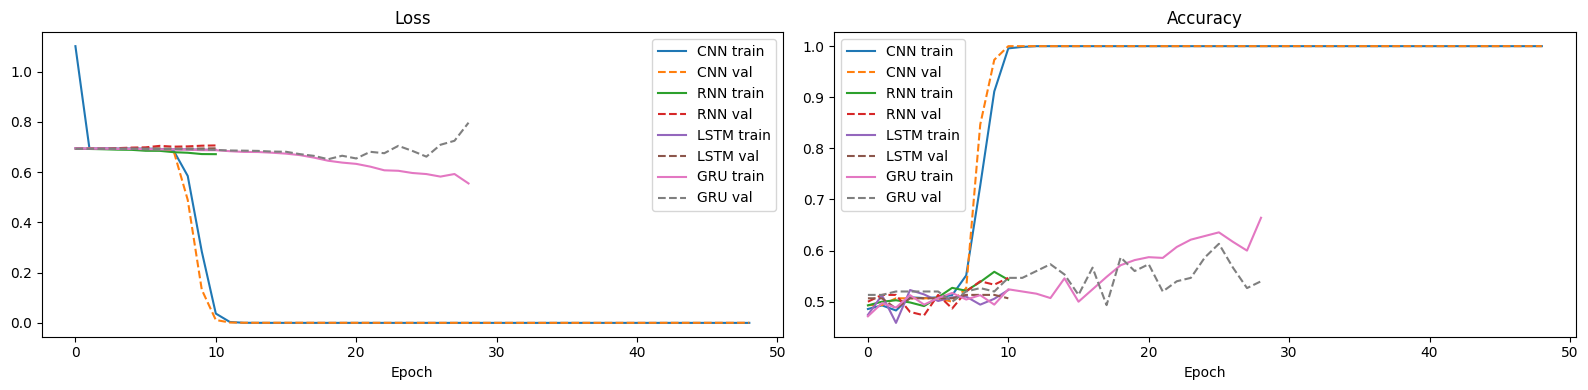

In [33]:
plot_history(all_histories)

## 8. Final test set evaluation

In [34]:
models  = {"CNN": cnn_model,     "RNN": rnn_model,     "LSTM": lstm_model,    "GRU": gru_model}
loaders = {"CNN": test_iter_cnn, "RNN": test_iter_rnn, "LSTM": test_iter_rnn, "GRU": test_iter_rnn}

test_results = {}
for name, model in models.items():
    test_results[name] = evaluate_model(model, loaders[name], label=name)


--- CNN results ---
  Accuracy   : 0.9867
  Macro F1   : 0.9867
  Weighted F1: 0.9867

              precision    recall  f1-score   support

    negative       0.97      1.00      0.99        74
    positive       1.00      0.97      0.99        76

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150


--- RNN results ---
  Accuracy   : 0.4933
  Macro F1   : 0.3304
  Weighted F1: 0.3348

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        74
    positive       0.50      0.97      0.66        76

    accuracy                           0.49       150
   macro avg       0.25      0.49      0.33       150
weighted avg       0.25      0.49      0.33       150


--- LSTM results ---
  Accuracy   : 0.5067
  Macro F1   : 0.3363
  Weighted F1: 0.3408

              precision    recall  f1-score   support

    negative       0.00   

In [35]:
print(f"{'Model':<8} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 44)
for name, r in test_results.items():
    print(f"{name:<8} {r['acc']:>10.4f} {r['macro_f1']:>10.4f} {r['weighted_f1']:>12.4f}")

Model      Accuracy   Macro F1  Weighted F1
--------------------------------------------
CNN          0.9867     0.9867       0.9867
RNN          0.4933     0.3304       0.3348
LSTM         0.5067     0.3363       0.3408
GRU          0.4667     0.4213       0.4235


## 9. Hyperparameter search: dropout and learning rate

Grid search on the small dataset. We pick best HP by val macro F1 so the test set stays untouched.

In [36]:
dropout_values = [0.0, 0.2, 0.5]
lr_values      = [1e-2, 1e-3, 1e-4]
hp_results     = []

for dropout in dropout_values:
    for lr in lr_values:
        m = CNN1DClassifier(context_size=NUM_STEPS, dropout=dropout)
        train_model(m, train_iter_cnn, val_iter_cnn, n_epochs=30, lr=lr)

        m.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_iter_cnn:
                preds = m(X_batch.to(device)).argmax(1).cpu()
                val_preds.extend(preds.tolist())
                val_targets.extend(y_batch.tolist())

        val_f1  = f1_score(val_targets, val_preds, average="macro", zero_division=0)
        val_acc = sum(p == t for p, t in zip(val_preds, val_targets)) / len(val_targets)

        hp_results.append({"dropout": dropout, "lr": lr, "val_acc": val_acc, "val_macro_f1": val_f1})
        print(f"dropout={dropout}, lr={lr:.0e}  ->  val_acc={val_acc:.3f}  val_macro_f1={val_f1:.3f}")

best_hp = max(hp_results, key=lambda r: r["val_macro_f1"])
print(f"\nBest HP: dropout={best_hp['dropout']}, lr={best_hp['lr']:.0e}  "
      f"->  val_macro_f1={best_hp['val_macro_f1']:.3f}")

Epoch   1/30  train loss=0.9821 acc=0.510  |  val loss=0.6928 acc=0.507
Epoch   5/30  train loss=0.6930 acc=0.507  |  val loss=0.6934 acc=0.507
Epoch  10/30  train loss=0.0288 acc=0.994  |  val loss=0.0303 acc=0.993
Epoch  15/30  train loss=0.0004 acc=1.000  |  val loss=0.0006 acc=1.000
Epoch  20/30  train loss=0.0001 acc=1.000  |  val loss=0.0010 acc=1.000
Epoch  25/30  train loss=0.0001 acc=1.000  |  val loss=0.0010 acc=1.000
  -> early stopping at epoch 25 (no improvement for 10 epochs)
dropout=0.0, lr=1e-02  ->  val_acc=1.000  val_macro_f1=1.000
Epoch   1/30  train loss=0.6996 acc=0.491  |  val loss=0.6930 acc=0.467
Epoch   5/30  train loss=0.5986 acc=0.750  |  val loss=0.6305 acc=0.693
Epoch  10/30  train loss=0.1427 acc=0.980  |  val loss=0.2279 acc=0.953
Epoch  15/30  train loss=0.0214 acc=1.000  |  val loss=0.0714 acc=0.987
Epoch  20/30  train loss=0.0072 acc=1.000  |  val loss=0.0397 acc=0.993
Epoch  25/30  train loss=0.0037 acc=1.000  |  val loss=0.0230 acc=1.000
Epoch  30/30

## 10. Effect of removing positive or negative examples

The project brief asks us to see what happens when we remove half the positives or half the negatives. From the previous run we already saw a clear result: removing half the positives completely breaks the model, removing half the negatives doesn't matter much.

In [37]:
def subsample_dataset(seqs, labs, mode):
    pos_idx = [i for i, l in enumerate(labs) if l == 1]
    neg_idx = [i for i, l in enumerate(labs) if l == 0]
    if mode == "half_positives":
        pos_idx = pos_idx[:len(pos_idx) // 2]
    elif mode == "half_negatives":
        neg_idx = neg_idx[:len(neg_idx) // 2]
    keep = sorted(pos_idx + neg_idx)
    return [seqs[i] for i in keep], [labs[i] for i in keep]


ratio_results = {}
for mode in ["full", "half_positives", "half_negatives"]:
    print(f"\n{'='*50}\n{mode}\n{'='*50}")
    if mode == "full":
        s, l = train_seqs, train_labs
    else:
        s, l = subsample_dataset(train_seqs, train_labs, mode)
    print(f"  pos={sum(l)}, neg={sum(1 for x in l if x==0)}")

    tr_loader = load_data(BATCH_SIZE, NUM_STEPS, (s, l), one_hot_enc=True)
    # use best_hp from section 9
    m = CNN1DClassifier(context_size=NUM_STEPS, dropout=best_hp["dropout"])
    train_model(m, tr_loader, val_iter_cnn, n_epochs=50, lr=best_hp["lr"])
    ratio_results[mode] = evaluate_model(m, test_iter_cnn, label=mode)

print(f"\n{'Condition':<20} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 56)
for mode, r in ratio_results.items():
    print(f"{mode:<20} {r['acc']:>10.4f} {r['macro_f1']:>10.4f} {r['weighted_f1']:>12.4f}")


full
  pos=355, neg=345
Epoch   1/50  train loss=1.1394 acc=0.523  |  val loss=0.6914 acc=0.507
Epoch   5/50  train loss=0.0127 acc=0.999  |  val loss=0.0421 acc=0.993
Epoch  10/50  train loss=0.0001 acc=1.000  |  val loss=0.0002 acc=1.000
Epoch  15/50  train loss=0.0000 acc=1.000  |  val loss=0.0005 acc=1.000
Epoch  20/50  train loss=0.0000 acc=1.000  |  val loss=0.0005 acc=1.000
  -> early stopping at epoch 20 (no improvement for 10 epochs)

--- full results ---
  Accuracy   : 0.9933
  Macro F1   : 0.9933
  Weighted F1: 0.9933

              precision    recall  f1-score   support

    negative       0.99      1.00      0.99        74
    positive       1.00      0.99      0.99        76

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150


half_positives
  pos=177, neg=345
Epoch   1/50  train loss=1.2375 acc=0.567  |  val loss=0.7677 acc=0.493
Epoch   5/50  train loss=0.61

## 11. Scale up to all six simulated datasets

Each dataset entry now has four values: name, max sequence length, learning rate, and dropout.

**Key fixes:**
- Small dataset (`len100_200_n1000`) gets `dropout=0.0` — this is what broke it in the previous run
- All 500aa datasets get `dropout=0.2` and `lr=1e-3`
- `nr2` gets extra epochs (100) and patience (15) since it's the hardest dataset

In [38]:
# (dataset name, max sequence length, learning rate, dropout, max epochs, patience)
DATASETS = [
    ("len100_200_n1000",    200, 1e-2, 0.0,  60,  10),  # small dataset needs dropout=0.0
    ("len200_500_n1000",    500, 1e-3, 0.2,  60,  10),
    ("len200_500_n5000nr1", 500, 1e-3, 0.2,  60,  10),
    ("len200_500_n5000nr2", 500, 1e-3, 0.2, 100,  15),  # harder dataset — more time
    ("len200_500_n5000nr3", 500, 1e-3, 0.2,  60,  10),
    ("len200_500_n5000nr4", 500, 1e-3, 0.2,  60,  10),
]

dataset_results = {}

for name, max_len, lr, dropout, n_epochs, patience in DATASETS:
    print(f"\n{'='*55}\nDataset: {name}  (lr={lr:.0e}, dropout={dropout})\n{'='*55}")

    dl, ll = read(f"{name}.seq", f"{name}.pos")
    tr_s, v_s, te_s, tr_l, v_l, te_l = generate_train_val_test(dl, ll)

    print(f"  Train: {len(tr_s)} | Val: {len(v_s)} | Test: {len(te_s)}  "
          f"(pos={sum(ll)}, neg={len(ll)-sum(ll)})")

    tr_iter = load_data(BATCH_SIZE, max_len, (tr_s, tr_l), one_hot_enc=True)
    v_iter  = load_data(BATCH_SIZE, max_len, (v_s,  v_l),  one_hot_enc=True, shuffle=False)
    te_iter = load_data(BATCH_SIZE, max_len, (te_s, te_l), one_hot_enc=True, shuffle=False)

    m = CNN1DClassifier(context_size=max_len, dropout=dropout)
    train_model(m, tr_iter, v_iter, n_epochs=n_epochs, lr=lr, patience=patience)

    dataset_results[name] = evaluate_model(m, te_iter, label=name)

# final summary across all six datasets
print(f"\n{'Dataset':<30} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 66)
for name, r in dataset_results.items():
    print(f"{name:<30} {r['acc']:>10.4f} {r['macro_f1']:>10.4f} {r['weighted_f1']:>12.4f}")


Dataset: len100_200_n1000  (lr=1e-02, dropout=0.0)
  Train: 700 | Val: 150 | Test: 150  (pos=507, neg=493)
Epoch   1/60  train loss=0.9678 acc=0.527  |  val loss=0.6929 acc=0.527
Epoch   5/60  train loss=0.6825 acc=0.504  |  val loss=0.6689 acc=0.507
Epoch  10/60  train loss=0.1570 acc=1.000  |  val loss=0.1446 acc=1.000
Epoch  15/60  train loss=0.0719 acc=1.000  |  val loss=0.0803 acc=0.993
Epoch  20/60  train loss=0.0436 acc=1.000  |  val loss=0.0638 acc=0.993
Epoch  25/60  train loss=0.0300 acc=1.000  |  val loss=0.0569 acc=0.993
Epoch  30/60  train loss=0.0223 acc=1.000  |  val loss=0.0536 acc=0.993
Epoch  35/60  train loss=0.0173 acc=1.000  |  val loss=0.0517 acc=0.993
Epoch  40/60  train loss=0.0139 acc=1.000  |  val loss=0.0525 acc=0.993
Epoch  45/60  train loss=0.0115 acc=1.000  |  val loss=0.0542 acc=0.993
  -> early stopping at epoch 45 (no improvement for 10 epochs)

--- len100_200_n1000 results ---
  Accuracy   : 0.9933
  Macro F1   : 0.9933
  Weighted F1: 0.9933

        